# LSTM Forecasting Model

We construct a Long Short-Term Memory (LSTM) model to forecast future electricity prices and carbon intensity.  
The model is trained on historical energy market data and learns temporal dependencies in order to generate multi-step forecasts.



## Model Objective

The goal of the model is to predict future values of:

- Electricity price $p_{t+i}$
- Carbon intensity $c_{t+i}$

for a forecast horizon of $H$ time steps.

The model uses a rolling window of past observations to produce these forecasts.



## Temporal Structure

We define:

- Input sequence length: $L$ (e.g., 48 hours)
- Forecast horizon: $H$ (e.g., 24 or 72 hours)

At each time step $t$, the model receives:

$$
X_t = [x_{t-L+1}, x_{t-L+2}, \dots, x_t]
$$

and outputs:

$$
Y_t = [y_{t+1}, y_{t+2}, \dots, y_{t+H}]
$$




## Output

The model predicts a vector:

$$
\hat{Y}_t \in \mathbb{R}^{H}
$$


## Training Objective

The model is trained using a loss function such as Mean Absolute Error (MAE):

$$
\mathcal{L} = \frac{1}{N} \sum_{t=1}^{N} \left| \hat{Y}_t - Y_t \right|
$$



## Data Pipeline

The data processing pipeline consists of:

1. Loading and merging datasets  
2. Generating lagged features  
3. Expanding structured columns (imports, exports, mix, flows)  
4. Encoding categorical variables  
5. Adding cyclical time features  
6. Creating future targets  
7. Removing missing values  
8. Scaling features  
9. Converting data into sequences of length $L$  


## Importing libraries

The following libraries are imported for use in the training enviroment:

In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import ast
from copy import deepcopy
import pickle
torch.manual_seed(6563952376042432591)

## Data Loading and Feature Engineering

This section prepares the dataset by combining multiple data sources and constructing relevant features for modeling.

### Data Loading

- The main dataset is merged with weather data from multiple locations (Denmark, Ringsted, Silkeborg).
- All data sources are aligned using a common `datetime` column.

### Feature Engineering

The pipeline includes:

- Lag features (e.g., $t-1$, $t-24$) to capture temporal dependencies  
- Optional extended lags for longer-term patterns  
- Rolling statistics (mean and standard deviation) to capture trends and variability  
- One-hot encoding of categorical variables (e.g., zones)  
- Expansion of structured columns (imports, exports, energy mix, flows) into numerical features  

### Data Cleaning

- Missing values are handled using forward filling and zero imputation  
- Irrelevant or redundant columns are removed  
- The final dataset consists only of numerical features suitable for model input  

### Evaluation Metrics

A helper function computes:

- Mean Absolute Error (MAE)  
- MAE normalized by the mean  
- MAE normalized by the standard deviation  

These metrics provide scale-independent evaluation of model performance.

In [20]:
weather_paths = {
    "dk": "hourly_data_Danmark_55.99775695800781_10.0052490234375.csv",
    "ring": "hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv",
    "silk": "hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv"
}
def load_and_merge(main_path, weather_paths):
    df_main = pd.read_csv(main_path)
    df_main["datetime"] = pd.to_datetime(df_main["datetime"])

    dfs = []
    for prefix, path in weather_paths.items():
        df = pd.read_csv(path)
        df["date"] = pd.to_datetime(df["date"])
        df = df.add_prefix(f"{prefix}_").rename(columns={f"{prefix}_date": "datetime"})
        dfs.append(df)

    df = df_main.copy()
    for d in dfs:
        df = df.merge(d, on="datetime", how="left")

    return df.sort_values("datetime")

def expand_json_column(df, col, prefix):
    df[col] = df[col].apply(ast.literal_eval)
    expanded = df[col].apply(pd.Series).add_prefix(prefix)
    return pd.concat([df.drop(columns=[col]), expanded], axis=1)


def basic_features(df, add_lags=True, extra_lags=None, add_rolling=False, rolling_windows_mean=None, rolling_windows_std=  None):
    df["hour"] = df["datetime"].dt.hour

    if add_lags:
        df["lag_1"] = df["value_spot"].shift(1)
        df["lag_2"] = df["value_spot"].shift(2)
        df["lag_24"] = df["value_spot"].shift(24)

    if extra_lags:
        for lag in extra_lags:
            df[f"lag_{lag}"] = df["value_spot"].shift(lag)

    if add_rolling:
        if rolling_windows_mean:
            for window in rolling_windows_mean:
                df[f"rolling_mean_{window}"] = df["value_spot"].shift(1).rolling(window=window).mean()
        if rolling_windows_std:
            for window in rolling_windows_std:
                df[f"rolling_std_{window}"] = df["value_spot"].shift(1).rolling(window=window).std()
    df = df.ffill()


    cat_cols = [c for c in ["zone_prev", "zone"] if c in df.columns]
    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Expand structured columns
    for col, prefix in [("import", "import_"), ("export", "export_")]:
        if col in df.columns:
            df = expand_json_column(df, col, prefix)

    if "mix" in df.columns:
        df["mix"] = df["mix"].apply(ast.literal_eval)
        df = pd.concat([df.drop(columns=["mix"]), df["mix"].apply(pd.Series)], axis=1)

    if "flows" in df.columns:
        df = df.join(df["flows"].apply(pd.Series))

    df = df.fillna(0)

    drop_cols = [
        "emissionFactorType", "battery storage", "hydro storage",
        "flows", "unit_spot", "unit_total_load"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

    return df


def performance_metrics(preds, actuals):
    mae = np.mean(np.abs(preds - actuals))
    maeOverMean = mae / np.mean(actuals)
    maeOverSTD = mae / np.std(actuals)
    print(f"MAE/Mean: {maeOverMean:.4f}, MAE/STD: {maeOverSTD:.4f}")


## Temporal Encoding, Target Construction, and Sequence Generation

This step augments the dataset with temporal features, constructs prediction targets, and converts the data into sequences suitable for LSTM modeling.

### Temporal Feature Encoding

Cyclical time features are encoded using sine and cosine transformations to preserve periodic structure:

- Hour of day (24-hour cycle)  
- Day of week (7-day cycle)  
- Month of year (12-month cycle)  

This representation avoids artificial discontinuities in time variables (e.g., hour 23 to 0).

### Target Construction

Future target variables are generated by shifting the base column forward:

$$
y_{t+i} = x_{t+i}, \quad i = 1, \dots, H
$$

This enables multi-step forecasting over a specified horizon $H$.

### Sequence Generation

The data is transformed into input-output sequences for LSTM training:

- Input: rolling windows of length $L$  
- Output: corresponding future targets  

Two modes are supported:

- **Training mode**: ensures sufficient future observations by offsetting by $L + H$  
- **Simulation mode**: uses only past information with offset $L$  

This structure enables the model to learn temporal dependencies while supporting both training and deployment scenarios.

In [21]:
def add_time_features(df):
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["weekday_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

    return df

def create_targets(df, base_col, horizon, prefix):
    for i in range(1, horizon + 1):
        df[f"{prefix}_t+{i}"] = df[base_col].shift(-i)
    return df

def create_sequences(X, Y, seq_len, horizon, to_simulation=False):
    X_seq, Y_seq = [], []

    if to_simulation:
        offset = seq_len
    else:
        offset = seq_len + horizon

    for i in range(len(X) - offset):
        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

## Data Preparation and Scaling

This step partitions the dataset into training, validation, test, and export subsets, followed by feature scaling.

### Data Splitting

- The dataset is divided temporally:
  - Data up to 2024-01-01 is used for model training and evaluation.
  - Data from 2023-12-30 onward is reserved for out-of-sample export and simulation.
- Missing values are removed from the training subset to ensure model stability.

The training data is further split into:
- Training set (70%)
- Validation set (15%)
- Test set (15%)

### Feature and Target Separation

- Input features $X$ are constructed by removing target and auxiliary columns.
- Targets $Y$ correspond to future values defined in `target_cols`.

### Feature Scaling

- A standard scaler is fitted on the training data and applied to all subsets.
- This ensures consistent feature distributions across training, validation, test, and export data.

This process ensures a clean separation between model development and out-of-sample evaluation.

In [22]:
def prepare_data(df, target_cols, drop_cols):
    dfToExport = df[df["datetime"] >= "2023-12-31"]
    dfToLSTM = df[df["datetime"] <= "2024-01-01"]
    dfToLSTM = dfToLSTM.drop(columns=["datetime"], errors="ignore").dropna()
    dfToExport = dfToExport.drop(columns=["datetime"], errors="ignore")

    exportX = dfToExport.drop(columns=target_cols+drop_cols).values
    exportY = dfToExport[target_cols].values

    X = dfToLSTM.drop(columns=target_cols + drop_cols).values
    Y = dfToLSTM[target_cols].values

    split1 = int(0.7 * len(X))
    split2 = int(0.85 * len(X))

    return (
        X[:split1], X[split1:split2], X[split2:],
        Y[:split1], Y[split1:split2], Y[split2:],
        exportX, exportY
    )

def scale_data(X_train, X_val, X_test, exportX):
    scaler = StandardScaler()
    return (
        scaler.fit_transform(X_train),
        scaler.transform(X_val),
        scaler.transform(X_test),
        scaler.transform(exportX),
        scaler
    )

## Model Architecture
The model is based on a multi-layer LSTM:

- Input: sequence of length $L$
- Hidden dimension: $h$
- Number of layers: $n$
- Dropout applied between layers

The LSTM encodes temporal dependencies and produces a hidden representation at each time step.  
We use the final time step output:

$$
h_t = \text{LSTM}(X_t)_{\text{last}}
$$

This representation is passed through a feedforward network:

$$
\hat{Y}_t = f(h_t)
$$

to produce the final forecast.

In [23]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



class LSTMModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

class LSTMModelCarbon(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

class LSTMModelPrice(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

## Model Training Procedure

This step defines the training routine for the LSTM model, including optimization, validation, and early stopping.

### Training Loop

The model is trained iteratively over a fixed number of epochs. For each epoch:

- Mini-batches are sampled from the training set  
- Inputs and targets are transferred to the selected computation device  
- Model parameters are updated using backpropagation and gradient-based optimization  

The training loss is accumulated across all batches.

### Validation

After each epoch, model performance is evaluated on a separate validation set:

- The model is set to evaluation mode  
- Gradients are disabled to improve efficiency  
- Validation loss is computed across all batches  

### Early Stopping

To prevent overfitting, an early stopping mechanism is applied:

- The model state with the lowest validation loss is stored  
- Training stops if validation performance does not improve for a predefined number of epochs (`patience`)  

### Model Selection

After training, the model is restored to the best-performing parameters observed during validation.

This procedure ensures stable training and promotes generalization to unseen data.

In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience, device):
    model = model.to(device)

    best_val = float("inf")
    best_weights = None
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(Xb)
            loss = criterion(outputs, yb)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        val_loss += len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train {train_loss:.4f} | Val {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_weights = {k: v.cpu() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping")
                break

    if best_weights:
        model.load_state_dict(best_weights)

    return model, train_losses, val_losses, best_val

### Plotting helper

splitting the predictions into a prediction array and an actuals array

In [25]:
def split_predictions(preds, actuals, horizon, split_type="both"):

    if split_type == "price":
        return preds, actuals

    elif split_type == "carbon":
        return preds, actuals

### Plotting results

Here we plot the loss function over an epoch counter as well as plotting our predictions on an inputted day

In [26]:
def plot_losses(train_losses, val_losses, title="Loss"):
    plt.figure()
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.legend()
    plt.title(title)
    plt.show()

def plot_prediction(y_true, y_pred, idx=0, title="Forecast", label="Value"):
    plt.figure()
    plt.plot(y_true[idx], label=f"Actual {label}")
    plt.plot(y_pred[idx], label=f"Predicted {label}")
    plt.legend()
    plt.title(title)
    plt.show()

## Prediction and Evaluation

This step performs model inference on unseen data and evaluates predictive performance.

### Prediction

The trained model is applied to the test dataset:

- The model is set to evaluation mode to disable training-specific behavior  
- Gradients are disabled to improve computational efficiency  
- Predictions are generated batch-wise and transferred to CPU for analysis  

The outputs are aggregated into full prediction and target arrays.

### Evaluation

Model performance is assessed using Mean Absolute Error (MAE):

$$
\text{MAE} = \frac{1}{N} \sum_{t=1}^{N} \left| \hat{y}_t - y_t \right|
$$

Evaluation can be performed for:

- Price forecasts  
- Carbon forecasts  
- Joint predictions (both price and carbon)

### Visualization

Predicted and actual time series are plotted for a selected sample to provide a qualitative assessment of model performance across the forecast horizon.

This step enables both quantitative and visual evaluation of the model's predictive accuracy.

In [27]:
def evaluate_and_plot(preds, actuals, horizon, mode="both", idx=0):
    print("\nFINAL RESULTS")

    if mode == "both":
        price_pred, carbon_pred, price_true, carbon_true = split_predictions(
            preds, actuals, horizon, "both"
        )

        print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
        print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")

        plot_prediction(price_true, price_pred, idx, "Price Forecast", "Price")
        plot_prediction(carbon_true, carbon_pred, idx, "Carbon Forecast", "Carbon")

    elif mode == "price":
        print(f"Price MAE: {np.mean(np.abs(preds - actuals)):.2f}")
        plot_prediction(actuals, preds, idx, "Price Forecast", "Price")

    elif mode == "carbon":
        print(f"Carbon MAE: {np.mean(np.abs(preds - actuals)):.2f}")
        plot_prediction(actuals, preds, idx, "Carbon Forecast", "Carbon")

def get_predictions(model, loader, device):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            preds.append(model(Xb).cpu().numpy())
            actuals.append(yb.numpy())

    return np.vstack(preds), np.vstack(actuals)

## Carbon Forecasting Pipeline

This section implements the end-to-end workflow for the carbon intensity forecasting model.

### Device Configuration

The computation device is selected dynamically based on hardware availability:

- CUDA (GPU) if available  
- Apple MPS backend if available  
- CPU otherwise  

This ensures efficient training across different environments.

### Model Scope

This pipeline corresponds specifically to the **carbon intensity forecasting model**.  
It is developed alongside a separate model for electricity price prediction, allowing for modular and task-specific learning.

### Data Processing

The dataset is processed through the following steps:

1. Data loading and merging with auxiliary sources  
2. Feature engineering and temporal encoding  
3. Target construction for carbon intensity forecasting  
4. Data splitting into training, validation, test, and export sets  
5. Feature scaling using a standard scaler  
6. Conversion into sequential input-output pairs  

### Model Training

- An LSTM model is initialized and transferred to the selected device  
- The model is trained using the Adam optimizer and Mean Absolute Error loss  
- Early stopping is applied based on validation performance  

### Prediction and Evaluation

- The trained model generates predictions on the test set  
- Performance is evaluated for carbon forecasts  
- Training and validation loss curves are visualized  

This pipeline ensures a consistent workflow from raw data to model evaluation for carbon intensity prediction.

In [28]:
if torch.cuda.is_available():
    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

HORIZON = 72
SEQ_LEN = 24
EPOCHS = 1000

df = load_and_merge("final_data.csv", weather_paths)
df = df[df["zone"] == "DK-DK1"].copy()
df = basic_features(df)
df = add_time_features(df)

df = create_targets(df, "carbonIntensity", HORIZON, "carbon")

target_cols = (
    [f"carbon_t+{i}" for i in range(1, HORIZON+1)]
)

X_train, X_val, X_test, Y_train, Y_val, Y_test, exportX, exportY = prepare_data(
    df, target_cols, ["hour", "day_of_week", "month"]
)

X_train, X_val, X_test, exportX, scaler = scale_data(X_train, X_val, X_test, exportX)

X_train, Y_train = create_sequences(X_train, Y_train, SEQ_LEN, HORIZON)
X_val, Y_val = create_sequences(X_val, Y_val, SEQ_LEN, HORIZON)
X_test, Y_test = create_sequences(X_test, Y_test, SEQ_LEN, HORIZON)
exportX, exportY = create_sequences(exportX, exportY, SEQ_LEN, HORIZON, to_simulation=True)

with open("exportDataCarbon.pkl", "wb") as f:
    pickle.dump((exportX, exportY), f)

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=False)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


Using device: cpu


In [ ]:
model = LSTMModel(X_train.shape[2], output_dim=Y_train.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss()


model, train_losses, val_losses, best_val = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    EPOCHS,
    patience=20,
    device=device
)

preds, actuals = get_predictions(model, test_loader, device=device)
performance_metrics(preds, actuals)
evaluate_and_plot(preds, actuals, HORIZON, mode="carbon", idx=200)
plot_losses(train_losses, val_losses)

### Pickle export file

In [ ]:

drop_cols = ["hour","day_of_week", "month"]


with open("lstm_model_carbon.pkl", "wb") as f:
    pickle.dump({
        "model_state": model.state_dict(),
        "scaler": scaler,
        "input_dim": X_train.shape[2],
        "features": df.drop(columns=target_cols + drop_cols).columns.tolist(),
        "HORIZON": HORIZON,
        "SEQ_LEN": SEQ_LEN,
        "example_input": None,
        "model": deepcopy(model),
        "model_class": LSTMModelPrice
    }, f)

## Price Forecasting Pipeline

This section implements the data preparation pipeline for the electricity price forecasting model.

### Model Scope

This pipeline corresponds to the **electricity price forecasting model**, developed alongside a separate model for carbon intensity prediction.  
The separation allows for task-specific feature engineering and model tuning.

### Data Filtering

- The dataset is restricted to a single price zone (DK-DK1) to ensure consistency in market dynamics.  

### Feature Engineering

The following features are constructed:

- Standard lag features ($t-1$, $t-2$, $t-24$)  
- Extended lag features (e.g., $t-168$ for weekly patterns)  
- Rolling statistics:
  - Mean over 24 and 168 hours  
  - Standard deviation over 24 hours  
- Cyclical time features (hour, weekday, month)  

These features capture both short-term and long-term temporal dependencies.

### Target Construction

Future electricity prices are generated over a forecast horizon of $H = 72$:

$$
y_{t+i} = p_{t+i}, \quad i = 1, \dots, H
$$

### Data Preparation

- The dataset is split into training, validation, test, and export sets  
- Both input features and targets are scaled independently using standard scaling  
- Data is transformed into sequences of length $L = 96$ for LSTM input  

### Data Loading

- The processed sequences are converted into PyTorch DataLoaders  
- Mini-batches are used for efficient training and evaluation  

This pipeline prepares the data for long-horizon electricity price forecasting using sequential deep learning models.

In [29]:
if torch.cuda.is_available():
    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
else:
    device = torch.device("cpu")

HORIZON = 72
SEQ_LEN = 24
EPOCHS = 1000


df = load_and_merge("final_data.csv", weather_paths)
df = df[df["zone"] == "DK-DK1"].copy()

df = basic_features(df, add_lags=True, extra_lags=[168], add_rolling=True, rolling_windows_mean=[24, 168], rolling_windows_std=[24])
df = add_time_features(df)

df = create_targets(df, "value_spot", HORIZON, "price")


target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON+1)]
)

X_train, X_val, X_test, Y_train, Y_val, Y_test, exportX, exportY = prepare_data(
    df, target_cols, ["hour", "day_of_week", "month"]
)

X_train, X_val, X_test, exportX, scaler = scale_data(X_train, X_val, X_test, exportX)
Y_train, Y_val, Y_test , exportY, y_scaler = scale_data(Y_train, Y_val, Y_test, exportY)


X_train, Y_train = create_sequences(X_train, Y_train, SEQ_LEN, HORIZON)
X_val, Y_val = create_sequences(X_val, Y_val, SEQ_LEN, HORIZON)
X_test, Y_test = create_sequences(X_test, Y_test, SEQ_LEN, HORIZON)
exportX, exportY = create_sequences(exportX, exportY, SEQ_LEN, HORIZON, to_simulation=True)

with open("exportDataPrice.pkl", "wb") as f:
    pickle.dump((exportX, exportY), f)

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)




Epoch 1: Train 87.3789 | Val 49.6555
Epoch 2: Train 67.4453 | Val 49.8974
Epoch 3: Train 61.7059 | Val 49.7474
Epoch 4: Train 57.9723 | Val 49.9213
Epoch 5: Train 53.8816 | Val 49.7840
Epoch 6: Train 49.2391 | Val 49.3271
Epoch 7: Train 44.0829 | Val 49.0973
Epoch 8: Train 40.3560 | Val 48.9162
Epoch 9: Train 38.2489 | Val 48.8973
Epoch 10: Train 36.6258 | Val 48.8788
Epoch 11: Train 35.3086 | Val 48.9222
Epoch 12: Train 34.2318 | Val 48.9423
Epoch 13: Train 33.2479 | Val 48.9927
Epoch 14: Train 32.3680 | Val 49.1743
Epoch 15: Train 31.7552 | Val 49.1288
Epoch 16: Train 31.2107 | Val 49.0434
Epoch 17: Train 30.4936 | Val 49.1086
Epoch 18: Train 29.9477 | Val 49.1906
Epoch 19: Train 29.6755 | Val 49.2389
Epoch 20: Train 29.1132 | Val 49.1114
Epoch 21: Train 28.6466 | Val 49.2400
Epoch 22: Train 28.3377 | Val 49.2399
Epoch 23: Train 27.9729 | Val 49.2217
Epoch 24: Train 27.4873 | Val 49.2703
Epoch 25: Train 27.1681 | Val 49.3380
Epoch 26: Train 26.9191 | Val 49.3156
Epoch 27: Train 26.62

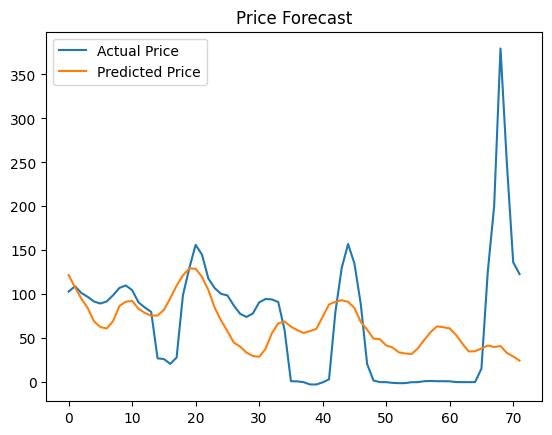

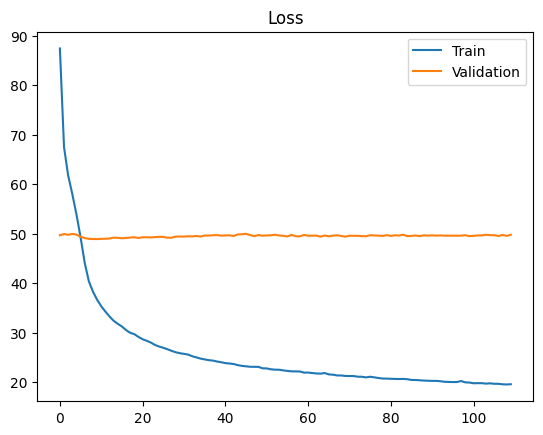

In [73]:
model = LSTMModelPrice(X_train.shape[2], output_dim=Y_train.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss()


model, train_losses, val_losses, best_val = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    EPOCHS,
    patience=100,
    device=device
)


preds, actuals = get_predictions(model, test_loader, device=device)

preds_real = y_scaler.inverse_transform(preds)
actuals_real = y_scaler.inverse_transform(actuals)

performance_metrics(preds_real, actuals_real)
evaluate_and_plot(preds_real, actuals_real, HORIZON, mode="price", idx=200)
plot_losses(train_losses, val_losses)

### Pickle export file

In [74]:

drop_cols = ["hour","day_of_week", "month"]


with open("lstm_model_price.pkl", "wb") as f:
    pickle.dump({
        #"model_state": model.state_dict(),
        #"scaler": scaler,
        #"input_dim": X_train.shape[2],
        #"features": df.drop(columns=target_cols + drop_cols).columns.tolist(),
        #"HORIZON": HORIZON,
        #"SEQ_LEN": SEQ_LEN,
        #"example_input": None,
        "model": deepcopy(model),
        #"model_class": LSTMModelPrice
    }, f)

## Model Output Usage

The trained model produces forecasts that can be used in:

- Simulation environments  
- Optimization problems (e.g., battery scheduling)  
- Decision-making systems  

At inference time, the model receives the latest $L$ time steps and outputs the next $H$ predictions.

## Extensions

Potential improvements include:

- Attention mechanisms for temporal weighting  
- Bidirectional LSTMs  
- Transformer-based models  
- Probabilistic forecasting (uncertainty estimation)  
- Incorporating exogenous forecasts (e.g., weather predictions)  